In [29]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import re

In [39]:
df= pd.read_csv('./data/_data.csv')
print("Первичный осмотр данных")


Первичный осмотр данных


In [40]:
#ПРоцент пустых значений для столбцов
df.isna().mean()

Unnamed: 0                  0.000000
ID  объявления              0.000000
Количество комнат           0.044548
Тип                         0.000000
Метро                       0.056274
Адрес                       0.000000
Площадь, м2                 0.000000
Дом                         0.000000
Парковка                    0.574161
Цена                        0.000000
Телефоны                    0.000000
Описание                    0.000000
Ремонт                      0.117896
Площадь комнат, м2          0.381291
Балкон                      0.341407
Окна                        0.282994
Санузел                     0.114344
Можно с детьми/животными    0.260870
Дополнительно               0.015277
Название ЖК                 0.749743
Серия дома                  0.907438
Высота потолков, м          0.520455
Лифт                        0.235365
Мусоропровод                0.450274
Ссылка на объявление        0.000000
dtype: float64

In [41]:
#выделение города из адреса
df[['Город', 'Адрес']]=df['Адрес'].str.split(',', n=1, expand=True)
df['Город']=df['Город'].str.strip()
df['Адрес']=df['Адрес'].str.strip()


In [42]:
# сохранение результата без СПб и Краснодара
df=df[~((df['Город']=='Санкт-Петербург') | (df['Город']=='Краснодарский край'))]


In [44]:
# Выделение столбцов этаж квартиры, этажность дома, тип дома
df[['этажи', 'тип_дома']] = df['Дом'].str.split(',', n=1, expand=True)
df[['этаж_квартиры', 'этажность_дома']] = df['этажи'].str.split('/', n=1, expand=True)

df['этаж_квартиры'] = df['этаж_квартиры'].str.strip()
df['этажность_дома'] = df['этажность_дома'].str.strip()
df['тип_дома'] = df['тип_дома'].str.strip()

df = df.drop('этажи', axis=1)

In [45]:
#Приведение лифтов к бинарному значению
df['Лифт'] = df['Лифт'].fillna(0)
df['Лифт'] = df['Лифт'].astype(bool).astype(int)

In [46]:
#Приведение паркинга к бинарному значению
df['Парковка'] = df['Парковка'].fillna(0)
df['Парковка'] = df['Парковка'].astype(bool).astype(int)

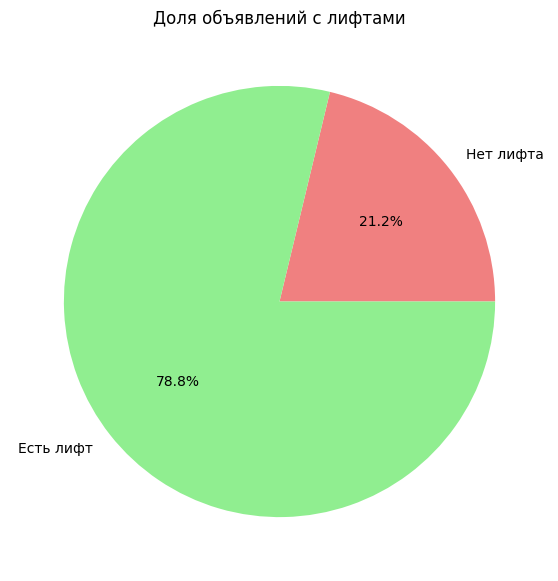

In [ ]:
#График наличие лифта
counts = df['Лифт'].value_counts().sort_index()
counts.index = ['Нет лифта', 'Есть лифт']

plt.figure(figsize=(7, 7))
plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%', colors=['lightcoral', 'lightgreen'])
plt.title('Доля объявлений с лифтами')
plt.show()

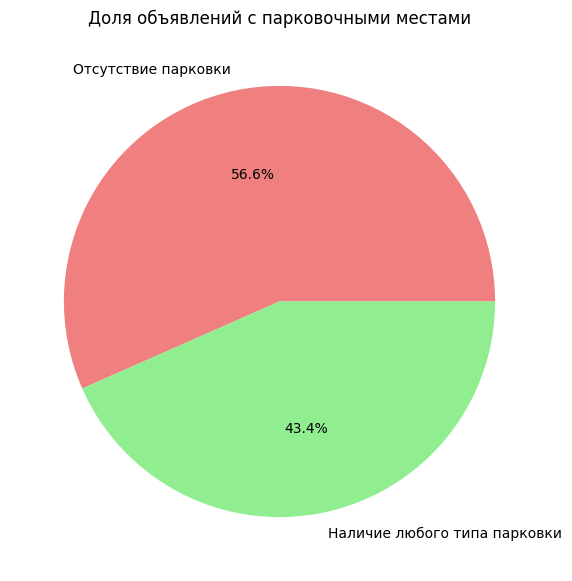

In [ ]:
#График наличие парковки
counts = df['Парковка'].value_counts().sort_index()
counts.index = ['Отсутствие парковки', 'Наличие любого типа парковки']

plt.figure(figsize=(7, 7))
plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%', colors=['lightcoral', 'lightgreen'])
plt.title('Доля объявлений с парковочными местами')
plt.show()

In [31]:
print(df['тип_дома'].value_counts(normalize=True) * 100)

тип_дома
Панельный              39.836574
Кирпичный              22.044614
Монолитный             21.561493
Блочный                10.073959
Монолитно-кирпичный     5.201002
Сталинский              0.840988
старый фонд             0.405583
Деревянный              0.029822
Щитовой                 0.005964
Name: proportion, dtype: float64


In [47]:
price = df['Цена'].apply(lambda x: int(x.split('.')[0]))
df['Цена'] = price
print(price[price != 0])

0        500000
1        500000
2        500000
3        400000
4        225000
          ...  
23363     42000
23364     45000
23365     50000
23366     55000
23367     57000
Name: Цена, Length: 19737, dtype: int64


In [48]:
print(f"\nМинимальная: {df['Цена'].min()}")
print(f"Максимальная: {df['Цена'].max()}")
print(f"Медиана: {df['Цена'].median()}")
print(f"Мода: {df['Цена'].mode()[0]}")
print(f"Дисперсия: {df['Цена'].var()}")
print(f"Стандартное отклонение: {df['Цена'].std()}")


Минимальная: 5000
Максимальная: 3000000
Медиана: 50000.0
Мода: 40000
Дисперсия: 16421991491.167233
Стандартное отклонение: 128148.31833140548


In [49]:
def clean_rooms(value):
    
    if pd.isna(value):
        return None
    #первое число в строке
    match = re.search(r'(\d+)', str(value))
    return int(match.group(1)) if match else None

df['Количество комнат'] = df['Количество комнат'].apply(clean_rooms)
df['Количество комнат'] = pd.to_numeric(df['Количество комнат'], errors='coerce').astype('Int64')

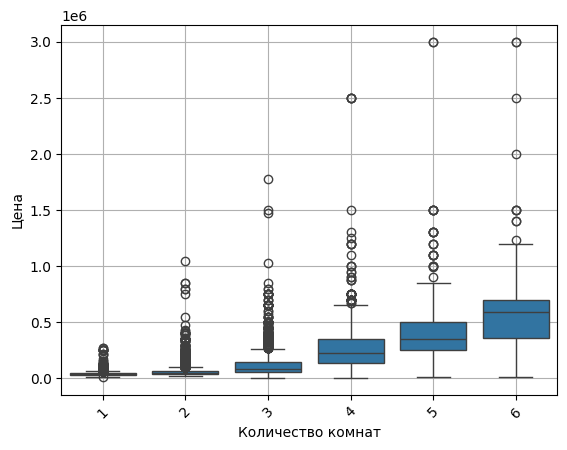

                    count           mean            std      min       25%  \
Количество комнат                                                            
1                  6655.0   41196.689406   15922.699453  12000.0   33000.0   
2                  7407.0   61670.525044   43802.730548  23999.0   42000.0   
3                  3668.0  121904.954471  108828.937781   5000.0   60000.0   
4                  1011.0  275740.840752  234635.597994   5000.0  140000.0   
5                   333.0  430950.504505  340799.281181   8081.0  250000.0   
6                   128.0  642093.742188  495593.955744  10000.0  360000.0   

                        50%       75%        max  
Количество комнат                                 
1                   38000.0   45000.0   270000.0  
2                   50000.0   65000.0  1050000.0  
3                   80000.0  141250.0  1775000.0  
4                  230000.0  350000.0  2500000.0  
5                  350000.0  500000.0  3000000.0  
6                 

In [35]:
sns.boxplot(data=df, x='Количество комнат', y = 'Цена')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()
print(df.groupby('Количество комнат')['Цена'].describe())

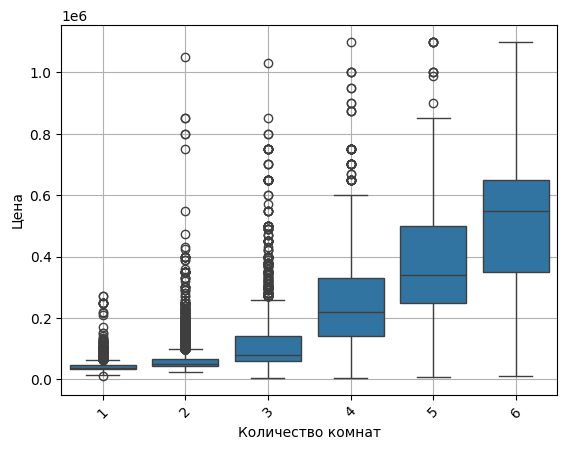

                    count           mean            std      min       25%  \
Количество комнат                                                            
1                  6655.0   41196.689406   15922.699453  12000.0   33000.0   
2                  7407.0   61670.525044   43802.730548  23999.0   42000.0   
3                  3665.0  120708.696589  100439.816131   5000.0   60000.0   
4                  1000.0  259923.990000  169350.157264   5000.0  140000.0   
5                   318.0  377064.522013  203839.875409   8081.0  250000.0   
6                   113.0  505769.902655  257249.197022  10000.0  350000.0   

                        50%       75%        max  
Количество комнат                                 
1                   38000.0   45000.0   270000.0  
2                   50000.0   65000.0  1050000.0  
3                   80000.0  140000.0  1030000.0  
4                  220000.0  330000.0  1100000.0  
5                  340000.0  500000.0  1100000.0  
6                 

In [53]:
sns.boxplot(data=df, x='Количество комнат', y = 'Цена')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()
print(df.groupby('Количество комнат')['Цена'].describe())

In [63]:
print(f"{95}% процентиль: {df.groupby('Количество комнат')['Цена'].quantile(95/100)}")
print(f"{5}% процентиль: {df.groupby('Количество комнат')['Цена'].quantile(5/100)}")

95% процентиль: Количество комнат
1      65000.0
2     120000.0
3     300000.0
4     650000.0
5     750000.0
6    1000000.0
Name: Цена, dtype: float64
5% процентиль: Количество комнат
1     27000.0
2     35000.0
3     45000.0
4     75000.0
5    108500.0
6     17200.0
Name: Цена, dtype: float64


In [70]:
df_6rooms = df[df['Количество комнат'] == 6]['Цена'].sort_values()

In [72]:
df_6rooms.head(10)

22729     10000
20258     10000
22762     10000
22732     10000
12853     10000
12852     10000
23141     22000
23142     23000
23143     23000
22838    110000
Name: Цена, dtype: int64

In [75]:
# отрезаем выбросы макс/мин 5% сверху и снизу

thresholds = {
    1: (27000, 65000),    # для 1-комнатных: от 27 до 65 тыс
    2: (35000, 120000),   # для 2-комнатных: от 35 до 120 млн
    3: (45000, 300000),   # для 3-комнатных: от 45 до 300 тыс
    4: (75000, 650000),   # для 4-комнатных: от 75 до 650 тыс
    5: (108500, 750000),  # для 5-комнатных: от 108,5 до 750 тыс
    6: (110000, 1000000)   # для 6-комнатных: от 110 до 1000 тыс 
}

def filter_by_thresholds(row):
    rooms = row['Количество комнат']
    price = row['Цена']
    
    if rooms in thresholds:
        low, high = thresholds[rooms]
        return low <= price <= high
    return True  

# Применяем фильтр
df_filtered = df[df.apply(filter_by_thresholds, axis=1)]

print(f"Было записей: {len(df)}")
print(f"Стало записей: {len(df_filtered)}")
print(f"Удалено: {len(df) - len(df_filtered)}")

Было записей: 19693
Стало записей: 18148
Удалено: 1545


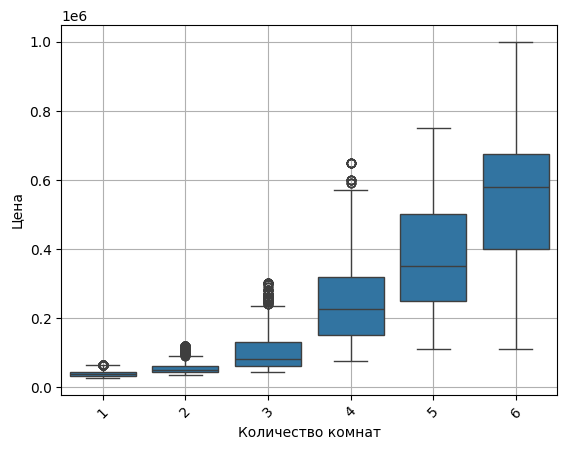

                    count           mean            std       min       25%  \
Количество комнат                                                             
1                  6087.0   39415.703138    8662.581625   27000.0   33000.0   
2                  6835.0   55243.104316   17935.822294   35000.0   43000.0   
3                  3383.0  105129.435117   59173.173176   45000.0   60000.0   
4                   915.0  246204.793443  127596.577627   75000.0  150000.0   
5                   290.0  368393.100000  151730.314879  110000.0  250000.0   
6                   103.0  542951.446602  215603.201784  110000.0  400000.0   

                        50%       75%        max  
Количество комнат                                 
1                   38000.0   45000.0    65000.0  
2                   50000.0   62000.0   120000.0  
3                   80000.0  130000.0   300000.0  
4                  225000.0  320000.0   650000.0  
5                  350000.0  500000.0   750000.0  
6         

In [77]:
sns.boxplot(data=df_filtered, x='Количество комнат', y = 'Цена')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()
print(df_filtered.groupby('Количество комнат')['Цена'].describe())